# From galaxy colours to spectroscopic redshift

## The scientific problem

Astronomical surveys obtain two complementary types of observations:

- **Imaging:** an object is observed through a small number of broad wavelength filters.
- **Spectroscopy:** the object's light is separated into many narrow wavelength bins, producing a spectrum as introduced in Lecture 1.

Spectroscopy contains much more detailed wavelength information, so it usually provides a much more precise redshift measurement. However, obtaining spectra for every detected galaxy is expensive, while imaging can be collected for many more objects.

In this exercise, we use galaxies for which both imaging and spectroscopy are available. The spectroscopic redshift, `z_spec`, is used as the target that teaches the model how redshift is encoded in photometry.

Our aim is to learn $p(z_{\rm spec}\mid\mathbf{x}_{\rm phot}),$ where $\mathbf{x}_{\rm phot}$ contains measurements derived from galaxy photometric imaging. In other words, we want to train a network to predict the spectroscopic redshift that is expensive to obtain from photometric measurements that are much cheaper to obtain.

In this notebook, we have two baseline examples:
- Deterministic MLP: it just predicts one spectroscopic redshift estimate for a given input.
- MDN: it predicts a full Gaussian-mixture probability distribution for the spectroscopic redshift for a given input. The network is deterministic but it outputs a PDF i.e. a generative model for each input.

---

## What is in the catalogue?

A **magnitude** is a logarithmic measure of brightness: a **smaller magnitude means a brighter object**.

A **colour** is the difference between two magnitudes, for example $u-g = u_{\rm mag}-g_{\rm mag}$.

Colours therefore describe the broad shape of a galaxy's spectrum rather than its overall brightness.

| Column | Meaning | Possible use |
|---|---|---|
| `raw_u-g`, `raw_g-r`, `raw_r-i`, `raw_i-z` | Colours calculated directly from the measured SDSS model magnitudes | These are the starter inputs, but they have not been corrected for foreground Milky Way extinction |
| `u-g`, `g-r`, `r-i`, `i-z` | The same colours after correcting each magnitude for foreground extinction | Potentially better estimates of the intrinsic observed galaxy colours |
| `r_mag` | Extinction-corrected apparent magnitude in the SDSS $r$ band | Adds the galaxy's overall apparent brightness, which is absent from colour differences |
| `concentration_r` | $R_{90}/R_{50}$, where $R_{50}$ and $R_{90}$ contain 50% and 90% of the galaxy's Petrosian $r$-band flux | A simple measure of how centrally concentrated the galaxy image is; it acts as a crude morphology feature |
| `z_spec` | Redshift $0.01 \lesssim z \lesssim 0.8$ measured from the galaxy spectrum | Supervised learning target |
| `source_id` | Unique row identifier | Used only to construct the Kaggle submission; never use it as a model input |
| `z_spec_err` | Reported uncertainty on `z_spec` | Optional extension discussed at the end of the notebook |

The starter model deliberately uses only the uncorrected colours:

```python
FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]
```
Possible improvements include replacing these inputs with extinction-corrected colours and adding `r_mag` and/or `concentration_r`.
There are also intentionally corrupted rows in the training data. The unchanged notebook produces a valid baseline submission, but inspecting and cleaning the data may improve your score.

## The Competition

- Each team may make at most **five** Kaggle submissions.
- Every submitted model must describe its prediction as a Gaussian mixture with **at most five components**. 
- The leaderboard uses the probability assigned to each hidden spectroscopic redshift, so **both** the predicted redshift **and** the predicted uncertainty matter.
- The hidden test targets are not corrupted. Models trained blindly on corrupted rows may generalise poorly, so careful inspection and cleaning can improve the leaderboard score.

In [1]:
from src import data, training, submission, models
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import functional as F

In [2]:
SEED = 42

AVAILABLE_FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
    "u-g",
    "g-r",
    "r-i",
    "i-z",
    "r_mag",
    "concentration_r",
]

# Deliberately basic starting point
FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]

HIDDEN_DIMS = [32]
DROPOUT = 0.0
LEARNING_RATE = 1.0e-3
N_EPOCHS = 15
PATIENCE = 4
N_COMPONENTS = 3
BATCH_SIZE = 1024

# Load the data


In [3]:
train_df, valid_df, test_df = data.load_data(
    feature_columns=[
        "source_id",
        *AVAILABLE_FEATURES,
        "z_spec",
    ]
)

In [4]:
train_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r,z_spec
0,75721,0.44290,0.29774,0.29979,0.06408,0.384739,0.234483,0.263315,0.037050,18.369424,2.705443,0.148594
1,80184,5.02115,1.73387,0.62599,0.29016,5.003120,1.714261,0.614683,0.281781,19.030725,3.061816,0.370307
2,19864,2.28812,1.31279,0.52009,0.36101,2.239757,1.260191,0.489760,0.338534,17.609765,3.021010,0.182686
3,76699,1.87708,1.19830,0.50219,0.33410,1.857378,1.176872,0.489834,0.324944,17.117362,2.549634,0.180082
4,80917,0.50164,1.34899,0.86997,0.37454,0.435289,1.276826,0.828359,0.343704,19.683500,2.798323,0.605213
...,...,...,...,...,...,...,...,...,...,...,...,...
64071,27678,1.74365,0.97650,0.46149,0.38368,1.649671,0.874288,0.402553,0.340004,16.831016,2.405889,0.113892
64072,6306,1.05312,0.40485,0.30957,0.09283,1.020338,0.369196,0.289011,0.077595,17.736201,2.382500,0.072956
64073,51901,1.78304,0.99550,0.38476,0.24892,1.768464,0.979647,0.375619,0.242146,20.048896,2.353180,0.452559
64074,6028,0.59766,1.28867,1.06208,0.50821,0.572651,1.261470,1.046396,0.496587,20.630726,2.439479,0.547846


In [5]:
valid_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r,z_spec
0,92991,1.91156,1.94902,0.70160,0.37451,1.871129,1.905047,0.676244,0.355720,18.962498,2.737058,0.367205
1,76434,2.92037,1.75815,1.01242,0.67781,2.895555,1.731161,0.996858,0.666277,20.909761,2.349823,0.583281
2,84004,-0.11385,1.82929,1.19212,0.55287,-0.129247,1.812544,1.182464,0.545714,20.926073,2.997971,0.633856
3,27701,1.08871,0.37458,0.40930,0.04915,1.075030,0.359702,0.400721,0.042792,21.517104,1.908549,0.119216
4,20424,1.72024,1.02679,0.46315,0.31903,1.694864,0.999191,0.447236,0.307237,17.278692,2.730738,0.142910
...,...,...,...,...,...,...,...,...,...,...,...,...
15919,83180,1.72914,2.78319,1.66269,0.46311,1.703982,2.755828,1.646913,0.451418,21.294683,2.222816,0.711628
15920,9909,1.37008,0.72134,0.40937,0.25838,1.268981,0.611385,0.345968,0.211395,17.054455,2.374385,0.084818
15921,88699,0.54443,1.33538,0.75609,0.46026,0.518875,1.307586,0.740064,0.448384,19.672415,2.716550,0.459087
15922,189,1.72685,0.91083,0.41862,0.34064,1.705935,0.888083,0.405503,0.330920,17.182251,2.496830,0.101179


In [6]:
test_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r
0,2,2.23806,1.54919,0.86700,0.32715,2.214140,1.523174,0.851999,0.316033,20.135875,2.554790
1,5,2.36749,1.32760,0.49687,0.30699,2.348379,1.306815,0.484885,0.298108,16.941856,2.917872
2,15,0.82951,0.55274,0.40419,0.36890,0.815074,0.537039,0.395136,0.362191,20.704527,2.361964
3,18,1.38557,0.81001,0.40175,0.27417,1.364970,0.787606,0.388831,0.264596,17.479351,2.357417
4,20,1.84895,1.48933,0.56390,0.40365,1.839585,1.479144,0.558027,0.399298,17.770558,2.698976
...,...,...,...,...,...,...,...,...,...,...,...
19995,99982,1.97421,1.29707,0.48153,0.35279,1.963267,1.285168,0.474667,0.347704,17.506245,3.170596
19996,99985,1.38385,1.53360,0.77773,0.54664,1.367477,1.515792,0.767462,0.539031,20.507349,2.069151
19997,99990,1.49611,1.66108,0.69359,0.43933,1.485636,1.649689,0.687022,0.434462,18.801652,3.234958
19998,99995,2.04467,1.77105,0.83585,0.40858,2.032491,1.757804,0.828212,0.402920,18.862138,2.390357


## Never blindly trust data

See Rule 0 of Lecture 2.

**Always manually look at as much data as possible and be very familiar with it!**

Always run quality checks. You never know what unexpected issues can be in it that reduce network performance. This is especially true for very large data sets as mistakes hide more easily due to low number statistics. 

TODO: There are intentionally corrupted samples in the training data 😈
- Visually inspect the data like in the sample plot below.
- Also check the data quality report that follows the plot

Decide what appears suspicious and whether to remove, replace, fix, or retain those samples.

Keep retraining as you clean up the data to see how the performance improves!

Hints:

- Are all colour values plausible?
- Are all target redshifts inside the range expected from the catalogue selection?
- Are any target values missing?
- Do you see isolated points or unusual structures in the colour-colour plot?
- Do raw and extinction-corrected colours give the same performance?

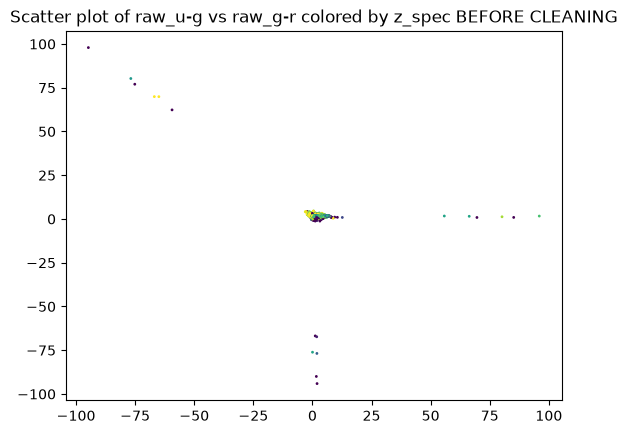

In [7]:
plt.title("Scatter plot of raw_u-g vs raw_g-r colored by z_spec BEFORE CLEANING")
plt.scatter(train_df['raw_u-g'], train_df['raw_g-r'], 
            c=train_df['z_spec'], 
            cmap='viridis', 
            s=1,
            vmin = 0.2,
            vmax = 0.7)
plt.show()

In [8]:
print("Training data quality report:")
data.print_quality_report(train_df)

Training data quality report:
                 count  missing  unique    mean     std     min       p01  median     p99    max
source_id        64076        0   64076   50127   28810       3      1016   50170   98979  99999
raw_u-g          64076        0   59087   1.639  1.4302 -94.774  -0.42677  1.6103  5.0424 95.948
raw_g-r          64076        0   56816  1.2176  1.1764 -94.055   0.23858  1.1664  2.3286 97.942
raw_r-i          64076        0   50900 0.62814  1.1551 -89.414   0.14001 0.52909  1.3294 95.622
raw_i-z          64076        0   44154 0.36126  1.1105 -97.474 -0.088605 0.35632 0.77976  89.96
u-g              64076        0   64066  1.6079  1.4301 -94.793  -0.46685  1.5782  5.0154  95.93
g-r              64076        0   64069  1.1838   1.177 -94.081   0.20637  1.1289  2.2985 97.921
r-i              64076        0   64060 0.60864  1.1553 -89.435   0.11838 0.50647   1.309 95.607
i-z              64076        0   64058 0.34681  1.1105 -97.481  -0.10491  0.3419  0.7684 89.944


,count,missing,unique,mean,std,min,p01,median,p99,max
source_id,64076.0,0,64076,50126.605437,28809.711630,3.000000,1016.000000,50169.500000,98978.750000,99999.000000
raw_u-g,64076.0,0,59087,1.638976,1.430180,-94.774280,-0.426765,1.610295,5.042400,95.947507
raw_g-r,64076.0,0,56816,1.217610,1.176378,-94.054704,0.238585,1.166380,2.328610,97.941760
raw_r-i,64076.0,0,50900,0.628141,1.155146,-89.413573,0.140010,0.529095,1.329433,95.622314
raw_i-z,64076.0,0,44154,0.361263,1.110513,-97.474070,-0.088605,0.356320,0.779757,89.959673
u-g,64076.0,0,64066,1.607875,1.430114,-94.793379,-0.466853,1.578206,5.015405,95.929689
g-r,64076.0,0,64069,1.183783,1.176965,-94.080539,0.206369,1.128942,2.298549,97.920988
r-i,64076.0,0,64060,0.608636,1.155346,-89.435029,0.118382,0.506466,1.308964,95.607417
i-z,64076.0,0,64058,0.346808,1.110501,-97.480813,-0.104913,0.341898,0.768398,89.943773
r_mag,64076.0,0,64071,18.573389,1.906473,11.227712,14.944761,18.227240,21.719753,112.789295


In [9]:
# CLEANING HINT
# Note this is not complete cleaning, but a starting point. 
# Improve on this baseline based on your observations.

# Remove extreme values from u-g color
mask = (train_df['raw_u-g'] < 13) & (train_df['raw_g-r'] <=6) & (train_df['raw_u-g'] > -2) & (train_df['raw_g-r'] > -26)
train_df = train_df[mask].reset_index(drop=True)
# Maybe also do this for other colors...?

# Drop rows with NaN values in the 'z_spec' column
train_df = train_df.dropna(subset=['z_spec']).reset_index(drop=True)

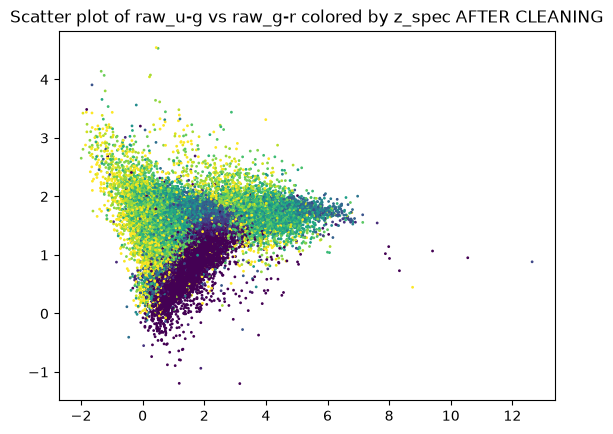

In [10]:
plt.title("Scatter plot of raw_u-g vs raw_g-r colored by z_spec AFTER CLEANING")
plt.scatter(train_df['raw_u-g'], train_df['raw_g-r'], 
            c=train_df['z_spec'], 
            cmap='viridis', 
            s=1,
            vmin = 0.2,
            vmax = 0.7)
plt.show()

In [11]:
print("Training data quality report AFTER CLEANING:")
data.print_quality_report(train_df)

Training data quality report AFTER CLEANING:
                 count  missing  unique    mean     std     min       p01  median     p99    max
source_id        63410        0   63410   50140   28815       3    1013.4   50210   98981  99999
raw_u-g          63410        0   58517  1.6397 0.99101  -1.994  -0.41716  1.6108  5.0355 12.641
raw_g-r          63410        0   56285  1.2177 0.48857 -1.1981   0.24264  1.1663  2.3219 4.5442
raw_r-i          63410        0   50474 0.62055 0.85738 -89.414   0.13988 0.52907  1.3286 2.7882
raw_i-z          63410        0   43807 0.36123  1.1161 -97.474 -0.088645 0.35631 0.77903  89.96
u-g              63410        0   63401  1.6086 0.99103 -2.0079  -0.44733  1.5786  5.0057 12.632
g-r              63410        0   63403  1.1839 0.48978 -1.2402   0.20967  1.1288  2.2884 4.5261
r-i              63410        0   63394 0.60103 0.85766 -89.435   0.11828 0.50645   1.308 2.7616
i-z              63410        0   63393 0.34677  1.1161 -97.481  -0.10525 0.34187 

,count,missing,unique,mean,std,min,p01,median,p99,max
source_id,63410.0,0,63410,50140.382952,28815.361563,3.000000,1013.360000,50210.000000,98980.730000,99999.000000
raw_u-g,63410.0,0,58517,1.639726,0.991014,-1.993960,-0.417156,1.610780,5.035453,12.640560
raw_g-r,63410.0,0,56285,1.217723,0.488566,-1.198110,0.242643,1.166260,2.321865,4.544180
raw_r-i,63410.0,0,50474,0.620545,0.857375,-89.413573,0.139878,0.529070,1.328640,2.788210
raw_i-z,63410.0,0,43807,0.361230,1.116093,-97.474070,-0.088645,0.356310,0.779028,89.959673
u-g,63410.0,0,63401,1.608613,0.991035,-2.007949,-0.447326,1.578589,5.005701,12.631597
g-r,63410.0,0,63403,1.183884,0.489778,-1.240173,0.209669,1.128795,2.288439,4.526142
r-i,63410.0,0,63394,0.601033,0.857655,-89.435029,0.118282,0.506447,1.308039,2.761599
i-z,63410.0,0,63393,0.346770,1.116081,-97.480813,-0.105250,0.341874,0.767099,89.943773
r_mag,63410.0,0,63405,18.565590,1.741549,11.227712,14.949880,18.227839,21.714664,22.432476


In [12]:
print("Training data quality report AFTER CLEANING:")
data.print_quality_report(train_df)
print("Validation data quality report AFTER CLEANING:")
data.print_quality_report(valid_df)

Training data quality report AFTER CLEANING:
                 count  missing  unique    mean     std     min       p01  median     p99    max
source_id        63410        0   63410   50140   28815       3    1013.4   50210   98981  99999
raw_u-g          63410        0   58517  1.6397 0.99101  -1.994  -0.41716  1.6108  5.0355 12.641
raw_g-r          63410        0   56285  1.2177 0.48857 -1.1981   0.24264  1.1663  2.3219 4.5442
raw_r-i          63410        0   50474 0.62055 0.85738 -89.414   0.13988 0.52907  1.3286 2.7882
raw_i-z          63410        0   43807 0.36123  1.1161 -97.474 -0.088645 0.35631 0.77903  89.96
u-g              63410        0   63401  1.6086 0.99103 -2.0079  -0.44733  1.5786  5.0057 12.632
g-r              63410        0   63403  1.1839 0.48978 -1.2402   0.20967  1.1288  2.2884 4.5261
r-i              63410        0   63394 0.60103 0.85766 -89.435   0.11828 0.50645   1.308 2.7616
i-z              63410        0   63393 0.34677  1.1161 -97.481  -0.10525 0.34187 

,count,missing,unique,mean,std,min,p01,median,p99,max
source_id,15924.0,0,15924,49790.663338,28868.457149,0.000000,1034.150000,49799.500000,99053.770000,99991.000000
raw_u-g,15924.0,0,15583,1.645836,1.009143,-3.452940,-0.465438,1.601110,5.128194,8.679980
raw_g-r,15924.0,0,15462,1.218379,0.494018,-0.857040,0.242759,1.160470,2.333067,4.596600
raw_r-i,15924.0,0,15003,0.629153,0.290837,-3.597930,0.134143,0.528910,1.324506,2.235400
raw_i-z,15924.0,0,14231,0.362429,0.170704,-2.724350,-0.072918,0.357470,0.792593,2.697780
u-g,15924.0,0,15921,1.614508,1.009110,-3.466339,-0.509735,1.569578,5.098956,8.652141
g-r,15924.0,0,15923,1.184305,0.495197,-0.872842,0.205310,1.125339,2.295301,4.540502
r-i,15924.0,0,15923,0.609506,0.291604,-3.613192,0.110129,0.506017,1.302732,2.222233
i-z,15924.0,0,15924,0.347869,0.171000,-2.730575,-0.082783,0.343065,0.781365,2.681496
r_mag,15924.0,0,15924,18.572444,1.731591,11.932400,14.974597,18.236486,21.671244,22.320530


# Feature engineering

We saw in Lecture 2 that network perfomance strongly depends on how what we give it as input. Both what quantities we input and how we pre-process them are therefore key for good performance. In particular, providing more informative input and pre-processing it can make the task easier for the NN to learn.

TODO: Default features are: 

FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]

How can we improve on this? 

Is there perhaps any more information we can pass to the network?

### Why `r_mag` may help

Four adjacent colours contain differences between five magnitudes. They therefore discard one degree of freedom: the overall brightness level.

For example, these two objects have identical colours: $(20,19,18,17,16)$ and $(23,22,21,20,19)$, but the second is three magnitudes fainter in every filter. Adding `r_mag` restores some of that missing brightness information.

That does not guarantee it will improve the model. It may encode a mixture of useful redshift information, intrinsic luminosity, and survey-selection effects.

### Why `concentration_r` may help

Two galaxies can have similar broad-band colours but different structures. `concentration_r` gives the network one crude piece of morphological information: $C_r=\frac{R_{90,r}}{R_{50,r}}$.

A centrally concentrated galaxy needs a relatively large radius to move from enclosing 50% to enclosing 90% of its light, producing a larger $C_r$. It is dimensionless and not the physical size of the galaxy.


After choosing our input, let's apply some simple pre-processing to the data:
- Standardize: subtract mean and std from the colors
- TODO: Improve the pre-processing step

In [13]:
# basic pre-processing
for feature in FEATURES:
    mean = train_df[feature].mean()
    std = train_df[feature].std()
    train_df[feature] = (train_df[feature] - mean) / std
    valid_df[feature] = (valid_df[feature] - mean) / std
    test_df[feature] = (test_df[feature] - mean) / std

In [14]:
# create data loaders
train_loader = data.create_data_loader(train_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = data.create_data_loader(valid_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.create_data_loader(test_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=False)

# Build and train network

In [15]:
mlp = models.MLPRegressor(
    n_features=len(FEATURES),
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
)

In [16]:
mlp_history = training.train_model(
    mlp,
    train_loader,
    valid_loader,
    loss_fn=lambda prediction, target: F.mse_loss(
        prediction,
        target,
    ),
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    patience=PATIENCE,
)

epoch 01/15 | train=37.87948 | valid=0.13781
epoch 02/15 | train=37.47427 | valid=0.20853
epoch 03/15 | train=37.35465 | valid=0.24852
epoch 04/15 | train=37.31025 | valid=0.28963
epoch 05/15 | train=37.29549 | valid=0.27926
early stopping after epoch 5


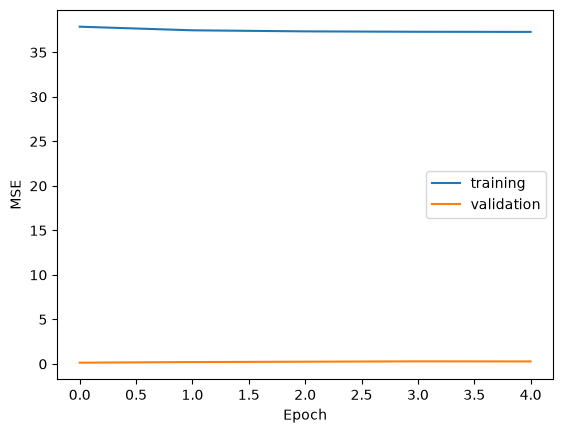

In [17]:
plt.plot(
    mlp_history["train_loss"],
    label="training",
)
plt.plot(
    mlp_history["valid_loss"],
    label="validation",
)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Basic Kaggle submission

Kaggle submission format is csv file with following format:
source_id; a_1, mu_1, sigma_1, a_2, mu_2, sigma_2, ..., a_5, mu_5, sigma_5


In [18]:
mlp_submission = submission.submission_from_point_model(
    mlp,
    test_loader,
    valid_loader,
    output_path="submissions/mlp_baseline.csv",
)

mlp_submission.head()

validation residual sigma = 0.340139
wrote submissions/mlp_baseline.csv with shape (20000, 16)


,source_id,a_1,mu_1,sigma_1,a_2,mu_2,sigma_2,a_3,mu_3,sigma_3,a_4,mu_4,sigma_4,a_5,mu_5,sigma_5
0,2,1.0,0.459789,0.340139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,5,1.0,0.438234,0.340139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,15,1.0,0.498777,0.340139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,18,1.0,0.361436,0.340139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,20,1.0,0.241524,0.340139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


# MDN Model

In [19]:
mdn = models.MDN(
    n_features=len(FEATURES),
    hidden_dims=HIDDEN_DIMS,
    n_components=N_COMPONENTS,
    dropout=DROPOUT,
)

In [20]:
mdn_history = training.train_model(
    mdn,
    train_loader,
    valid_loader,
    loss_fn=models.mdn_nll,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    patience=PATIENCE,
)

epoch 01/15 | train=20.85388 | valid=0.30110
epoch 02/15 | train=11.19342 | valid=-0.35148
epoch 03/15 | train=6.45774 | valid=-0.84540
epoch 04/15 | train=3.92685 | valid=-1.05800
epoch 05/15 | train=2.46927 | valid=-1.27135
epoch 06/15 | train=1.55797 | valid=-1.35815
epoch 07/15 | train=0.94520 | valid=-1.46500
epoch 08/15 | train=0.50399 | valid=-1.52515
epoch 09/15 | train=0.18013 | valid=-1.56327
epoch 10/15 | train=-0.06812 | valid=-1.59607
epoch 11/15 | train=-0.27413 | valid=-1.64263
epoch 12/15 | train=-0.44600 | valid=-1.68016
epoch 13/15 | train=-0.58990 | valid=-1.70410
epoch 14/15 | train=-0.70199 | valid=-1.72694
epoch 15/15 | train=-0.79270 | valid=-1.73219


In [21]:
mdn_submission = submission.submission_from_prob_model(
    mdn,
    test_loader,
    output_path="submissions/mdn_baseline.csv",
)

mdn_submission.head()

wrote submissions/mdn_baseline.csv with shape (20000, 16)


,source_id,a_1,mu_1,sigma_1,a_2,mu_2,sigma_2,a_3,mu_3,sigma_3,a_4,mu_4,sigma_4,a_5,mu_5,sigma_5
0,2,0.928788,0.439446,0.043328,0.020077,4.936341,3.919005,0.051135,0.538144,0.251938,0.0,0.0,1.0,0.0,0.0,1.0
1,5,0.934891,0.192791,0.023084,0.014220,5.285933,4.166088,0.050889,0.283825,0.283724,0.0,0.0,1.0,0.0,0.0,1.0
2,15,0.916289,0.149003,0.057351,0.010659,6.851231,4.885711,0.073052,0.419757,0.753762,0.0,0.0,1.0,0.0,0.0,1.0
3,18,0.958712,0.116173,0.028209,0.008874,5.902108,4.450255,0.032414,0.257633,0.574710,0.0,0.0,1.0,0.0,0.0,1.0
4,20,0.961273,0.269539,0.032152,0.012253,5.233289,4.121834,0.026474,0.335710,0.344217,0.0,0.0,1.0,0.0,0.0,1.0


## Optional extension: uncertainty in the spectroscopic target

The training catalogue also contains `z_spec_err`, the reported uncertainty on the spectroscopic redshift.

This quantity is **not an input feature**. A galaxy with only photometric observations would not have either `z_spec` or `z_spec_err`. Instead, `z_spec_err` describes uncertainty in the supervised-learning label.

The notebook ignores this uncertainty and treats `z_spec` as the target value. But there are some more advanced ways to use it.

### 1. Data-quality check

Rule 0 from Lecture 2 still applies! Inspect the distribution of `z_spec_err`. Missing, negative, or unusually large values may identify unreliable labels that should be removed or treated separately.

### 2. Compare spectroscopic and photometric uncertainty

The MDN predicts a redshift distribution. For a Gaussian mixture, its predictive mean is
$$\bar z = \sum_k a_k\mu_k,$$

and its total predictive variance is

$$\sigma_{\rm pred}^2 = \sum_k a_k\left(\sigma_k^2+\mu_k^2\right) -\bar z^2.$$

This total mixture uncertainty can be compared with `z_spec_err`.

We normally expect the uncertainty inferred from five-band photometry to be much larger than the spectroscopic measurement uncertainty. However, this is a qualitative diagnostic rather than a strict per-object rule. In particular, an individual mixture-component width is not the same as the total uncertainty of a multimodal mixture.

### 3. Include label uncertainty in the loss

Suppose the MDN predicts the distribution of the underlying redshift,

$$ p_\phi(z\mid\mathbf{x}) = \sum_k a_k\, \mathcal N(z\mid\mu_k,\sigma_k^2).$$


If the measured spectroscopic redshift has Gaussian uncertainty $\sigma_{{\rm spec},i}$, the likelihood of the observed label becomes

$$ p_\phi(z_{{\rm spec},i}\mid\mathbf{x}_i) = \sum_k a_{ik}\, \mathcal N\left( z_{{\rm spec},i} \mid \mu_{ik}, \sigma_{ik}^2+\sigma_{{\rm spec},i}^2\right).$$

Thus, the spectroscopic uncertainty can be included by adding it in quadrature to every predicted component width during training:

$$\sigma_{{\rm total},ik} = \sqrt{ \sigma_{ik}^2+ \sigma_{{\rm spec},i}^2}.$$

This is an optional advanced task and is not required for a valid Kaggle submission.

# TODO: tune the models

Suggestions:
- Vary hidden layer number
- Vary number of neurons
- Vary number of components K=1,2,3,5
- Vary the dropout fraction
- Vary the initial learning rate
- Vary the number of epochs
- Vary the early stopping patience
- Vary pre-processing steps

I suggest to only change one thing at a time so you actually know what improves performance and what doesn't.
Keep careful track of changes and perfomance, for example, using this kind of table:

| Model | Features | Cleaning | K | Validation RMSE | Validation NLL | Runtime |
| ----- | -------- | -------- | --: | --------------: | -------------: | ------: |


# Final submission

Call `write_submission` and print:
- path
- model description
- validation score

Kaggle submission message format:

    team=Orion | model=MDN K=3 64x64 |
    features=colors+errors | cleaning=flags+range